In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
import statsmodels.formula.api as smf
matplotlib.rc('font', serif='Helvetica Neue') 

In [2]:
KO = pd.read_csv('receptorKO.csv')

# spontaneous aggressive percentage

In [3]:
size = KO[(KO.injection_site == 'MPOA') &
              (KO.virus == 'EGFP-CRE')].groupby(['state_before', 'KO']).size().reset_index(name='count')

size['total'] = size.groupby(['state_before', 'KO'])['count'].transform('sum')

size['percentage'] = size['count'] / size['total'] * 100

# Calculate counts where 'state_before' is 'state2' for each genotype
state2_counts = size[size['state_before'] == 'Agg-'].groupby('KO')['count'].sum()

# Calculate Agg- percentage for each genotype as 1 - (state2 percentage)
size['agg_plus_percentage'] = size['KO'].map(
    lambda ko: 100 * (1 - (state2_counts.get(ko, 0) / size[(size['KO'] == ko) & (size['state_before'] == 'Agg-')]['total'].values[0])))


small_value = 2
size.loc[size['agg_plus_percentage'] == 0, 'agg_plus_percentage'] += small_value


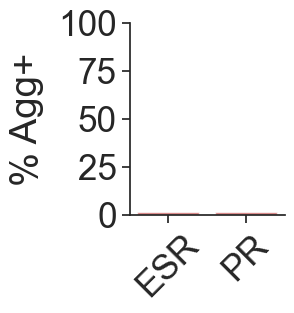

In [4]:
sns.set(font_scale=2.3)
sns.set_style('ticks')

plt.figure(figsize=(2, 2.5))
sns.barplot(x='KO', y='agg_plus_percentage', data=size,  color='Tab:red', alpha=0.7)
sns.despine()
plt.ylabel('% Agg+', labelpad=10)
plt.xlabel('')
plt.ylim(0, 100)
plt.xticks(rotation=45)
ax = plt.gca()
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.savefig('spontaneous_agg_ko.png', bbox_inches='tight', dpi=300, transparent=True)


# using detection profile (all data)

In [6]:
esrs = ['JKAH24.1e', 'JKAH27.2d', 'JKAH27.2e', 
       'JKAH27.2h', 'JKAH28.1f', 'JKAH28.1g', 
       'JKAH29.1f', 'JKAH30.1d', 'JKAH30.1e']

prs =  ['JKAX4.3d', 'JKAX4.3e', 'JKAX6.2e','JKAX6.2f', 'JKAX6.2g', 
        'JKAX6.2h', 'JKAX7.3b',  'JKAX12.1d','JKAX12.1e', 'JKAX12.3d']

path = '~/Documents/negative_parental_switch/NPW_hormone/receptor_KO/quantification/'
# path = '/Users/kohlj/Dropbox (Personal)/Science/Crick/PROJECTS/negative_parental_switch/NPW_hormone/receptor_KO/quantification/'


knockout = prs #esrs / prs
dfs = []
for id in knockout:
    df = pd.read_csv(path + id +'_detection.csv')
    
    df['mice_ID'] = [id] * df.shape[0]
    dfs.append(df)

dfs = pd.concat(dfs, ignore_index = True)

In [7]:
knockout

['JKAX4.3d',
 'JKAX4.3e',
 'JKAX6.2e',
 'JKAX6.2f',
 'JKAX6.2g',
 'JKAX6.2h',
 'JKAX7.3b',
 'JKAX12.1d',
 'JKAX12.1e',
 'JKAX12.3d']

In [8]:
parental_behaviours = [ 'pup groom', 'retrieval to nest', 'nest time', 'nest building']
pr_behav = pd.read_csv('MPOA_progesterone_KO_behav.csv')
pr_behav['mice_ID'] = pr_behav['Observation id'].str[:-5]
parental_time = pr_behav[pr_behav.Behavior.isin(parental_behaviours)].groupby('mice_ID')['Duration (s)'].sum().reset_index(name = 'parental_time')

In [9]:
threshold = dfs['Cytoplasm: Opal 520 mean']

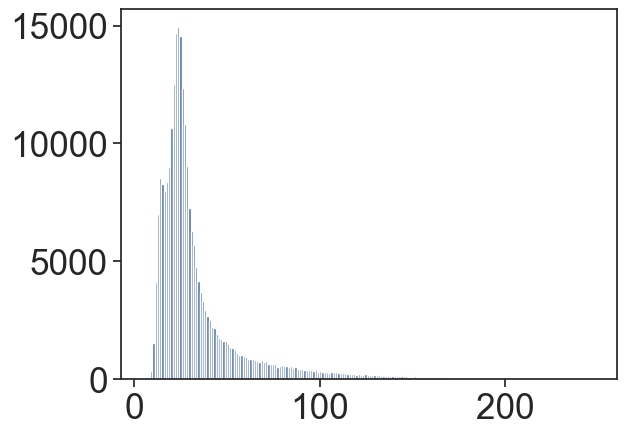

In [10]:
plt.subplot()
plt.rcParams["figure.figsize"] = (4,2)
counts, bins, bars = plt.hist(threshold, bins = 200)
hist_df = pd.DataFrame({'bins':bins[1:], 'counts':counts})

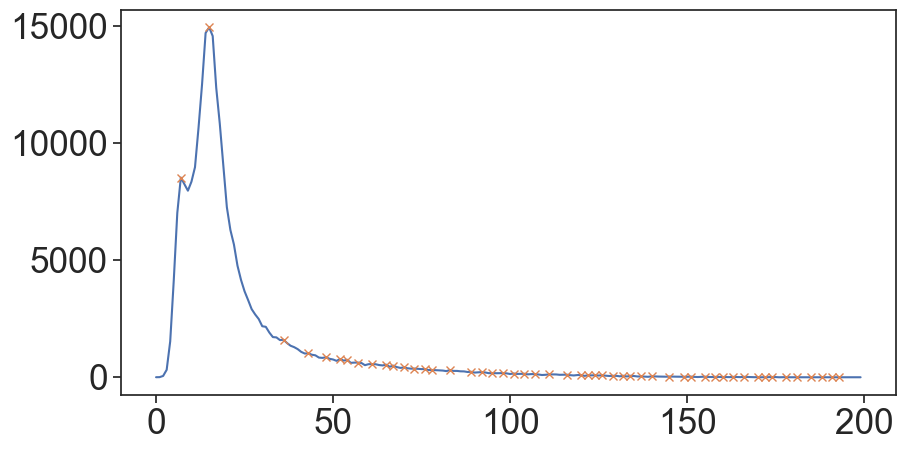

In [11]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(hist_df.counts, height=0)
plt.rcParams["figure.figsize"] = (10,5)
plt.plot(hist_df.counts)
plt.plot(hist_df.loc[peaks].counts, "x")
plt.show()

In [12]:
if knockout == prs:
    t = hist_df.loc[peaks].bins.tolist()[1]
else:
    t = hist_df.loc[peaks].bins.tolist()[0]

In [13]:
filtered_df = dfs[dfs['Cytoplasm: Opal 520 mean'] > t]
filtered_df = filtered_df.groupby(by = ['mice_ID'])['Cytoplasm: Opal 520 mean'].count().reset_index(name = 'count')

In [14]:
KO_dat = pd.merge(filtered_df, KO, on = 'mice_ID')

if knockout == prs:
    KO_dat = pd.merge(KO_dat, parental_time, on = 'mice_ID')
    
KO_dat = KO_dat[KO_dat.mice_ID.isin(knockout)]
KO_dat['dummy_x'] = [0] * KO_dat.shape[0]

In [14]:
# plt.rcParams["figure.figsize"] = (10,3)
# if knockout == prs:

#     sns.lmplot(data=KO_dat, x="count", y = 'parental_time',
#                height=3, aspect=1.5,
#                scatter_kws = {'color' :'purple', 'alpha':0.5},
#                line_kws = {'color' :'purple', 'alpha': 0.3})
#     sns.despine()
    
#     plt.xticks(fontsize = 12)
#     plt.yticks(fontsize = 12)
#     plt.xlabel('Number of KO cells', fontsize = 14)
#     plt.ylabel('Total parenting time (s)', fontsize = 14)
    
#     plt.savefig('progesterone_KO_quantification.jpg', dpi= 300)
#     plt.show()
# else:
#     g = sns.lmplot(data=KO_dat, x="count", y = 'state_after_latency', 
#                    height=3, aspect=1.5, 
#                    scatter_kws = {'color' :'lightblue'},
#                    line_kws = {'color' :'lightblue', 'alpha': 0.5})
#     sns.despine()
    
#     plt.xticks(fontsize = 12)
#     plt.yticks(fontsize = 12)
#     plt.xlabel('Number of KO cells', fontsize = 14)
#     plt.ylabel('Attack latency (s)', fontsize = 14)
    
#     plt.savefig('estradiol_KO_quantification.jpg', dpi= 300)
#     plt.show()

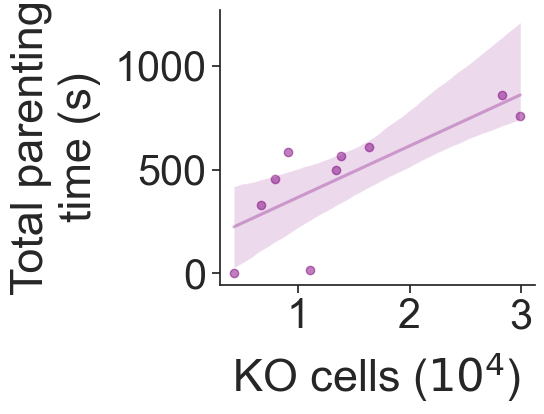

In [16]:
# new version
KO_dat['count_new'] = KO_dat['count'] / 10000

if knockout == prs:

    sns.set(font_scale=2.7) 
    sns.set_style("ticks")

    sns.lmplot(data=KO_dat, x="count_new", y = 'parental_time', scatter_kws = {'color' :'purple', 'alpha':0.5},
               line_kws = {'color' :'purple', 'alpha': 0.3}, height=4.7, aspect=1.2)
    sns.despine()
    
    plt.xlabel('KO cells ($10^{4}$)', labelpad=10)
    plt.ylabel('Total parenting\ntime (s)', labelpad=10)

    # plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/progesterone_KO_quantification.pdf',
    #             dpi=600,bbox_inches='tight', transparent=True)
else:
    sns.set(font_scale=2.7) 
    sns.set_style("ticks")

    sns.lmplot(data=KO_dat, x="count_new", y = 'state_after_latency', scatter_kws = {'color' :'lightblue', 'alpha':1},
               line_kws = {'color' :'lightblue', 'alpha': 1}, height=4.7, aspect=1.2)
    sns.despine()
    
    plt.xlabel('KO cells ($10^{4}$)', labelpad=10)
    plt.ylabel('Attack latency (s)', labelpad=10)

#     plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/estrogen_KO_quantification.pdf',
#                 dpi=600,bbox_inches='tight', transparent=True)

In [17]:
## statistic tests
if knockout == prs:
    model = smf.ols('count ~ parental_time ', data=KO_dat).fit()
    print(model.summary())
    p_values = model.pvalues
    print("\nP-values:")
    print(p_values)
else:
   
    model = smf.ols('count ~ state_after_latency ', data=KO_dat).fit()
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     11.09
Date:                Sun, 07 Sep 2025   Prob (F-statistic):             0.0104
Time:                        22:27:06   Log-Likelihood:                -100.05
No. Observations:                  10   AIC:                             204.1
Df Residuals:                       8   BIC:                             204.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      3089.1610   3806.542      0.812

/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [17]:
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
parental_time,3.979982e+08,1.0,11.089187,0.010384
Residual,2.871252e+08,8.0,NaN,NaN


# per slice measurement

In [18]:
esrs = ['JKAH24.1e', 'JKAH27.2d', 'JKAH27.2e', 
       'JKAH27.2h', 'JKAH28.1f', 'JKAH28.1g', 
       'JKAH29.1f', 'JKAH30.1d', 'JKAH30.1e']
prs =  ['JKAX4.3e', 'JKAX6.2e','JKAX6.2f', 'JKAX6.2g', 'JKAX6.2h',
       'JKAX7.3b', 'JKAX7.3c', 'JKAX12.1d',
       'JKAX12.1e', 'JKAX12.3d']
ids = esrs + prs

path = '~/Desktop/PhD_materials/negative_parental_switch/NPW_hormone/receptor_KO/threshold_5/'
areas = [ "MPO", "MPN", "PS","PD", "ADP"]
dfs = []
for id in ids:
    df = pd.read_csv(path + id +'_detection.csv')
    
    df['mice_ID'] = [id] * df.shape[0]
    df = df.groupby(by = 'mice_ID').sum().reset_index()
    dfs.append(df)

dfs = pd.concat(dfs, ignore_index = True)
KO_dat = pd.merge(dfs, KO, on = 'mice_ID')
KO_dat['detection_area'] = KO_dat['Num Detections']/ KO_dat['Area µm^2']

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kohlj/Desktop/PhD_materials/negative_parental_switch/NPW_hormone/receptor_KO/threshold_5/JKAH24.1e_detection.csv'

## esr1 quantification

In [ ]:
esr = KO_dat[KO_dat.mice_ID.isin(esrs)]

In [ ]:
g = sns.lmplot(data=esr, x="detection_area", y = 'state_after_latency')
sns.despine()
plt.show()

In [ ]:
model = smf.ols('detection_area ~ state_after_latency ', data=esr).fit()
model.summary()

In [ ]:
sm.stats.anova_lm(model, typ=2)

## PR quantification

In [ ]:
pr = KO_dat[KO_dat.mice_ID.isin(prs)]
pr['dummy_x'] = [0] * pr.shape[0]

In [ ]:
g = sns.stripplot(data=pr, x="detection_area", y = 'dummy_x', hue = 'state')
sns.despine()
plt.show()

In [ ]:
model = smf.ols('detection_area ~ C(state) ', data=pr).fit()
model.summary()

In [ ]:
sm.stats.anova_lm(model, typ=2)